# Retrieve customer.io user data

In [1]:
from Customerio_Event_Data_utils import retrieve_event_summary
import pandas as pd

summary_df = retrieve_event_summary()
summary_df.head()

event_name,app_login,clicked,email_opened
date,,,
2024-10-26,80,84,83
2024-10-27,74,93,82
2024-10-28,68,88,91
2024-10-29,79,88,85
2024-10-30,85,76,79


# Aggregate Weekly Counts

In [2]:
summary_df.index = pd.to_datetime(summary_df.index)  # ensure index is datetime

weekly_summary = summary_df.resample("W").sum()
weekly_summary.head()

event_name,app_login,clicked,email_opened
date,,,
2024-10-27,154,177,165
2024-11-03,531,576,582
2024-11-10,631,582,616
2024-11-17,638,634,570
2024-11-24,585,606,592


# Visualize Daily Trends

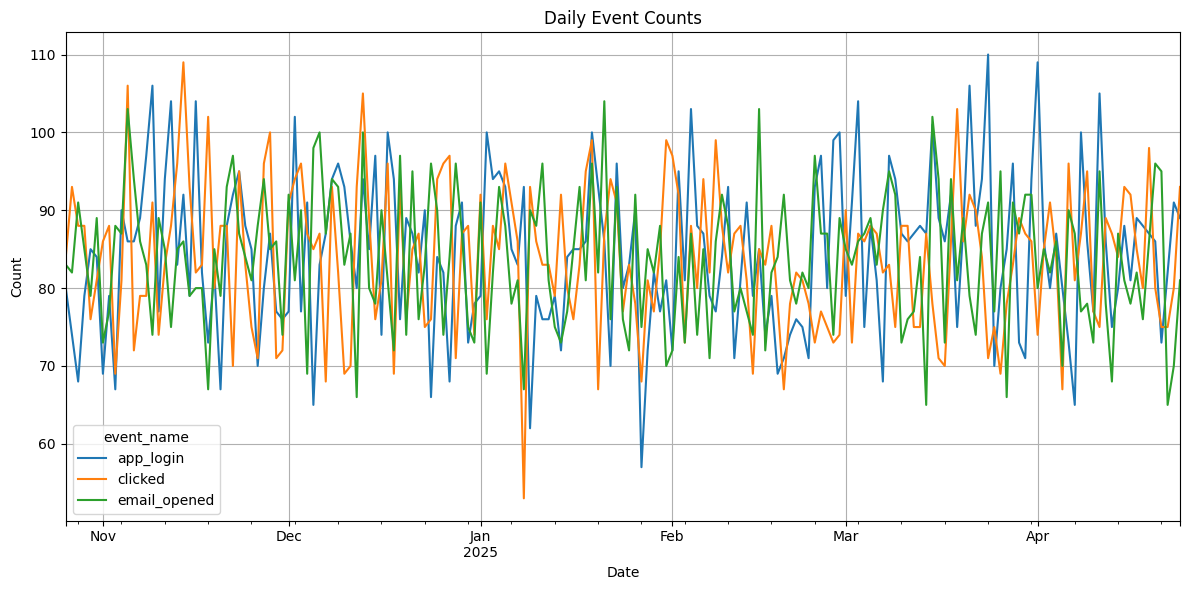

In [3]:
import matplotlib.pyplot as plt

summary_df.plot(figsize=(12, 6), title="Daily Event Counts")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

# Detect Campaign Spikes (Basic Trend Insight)

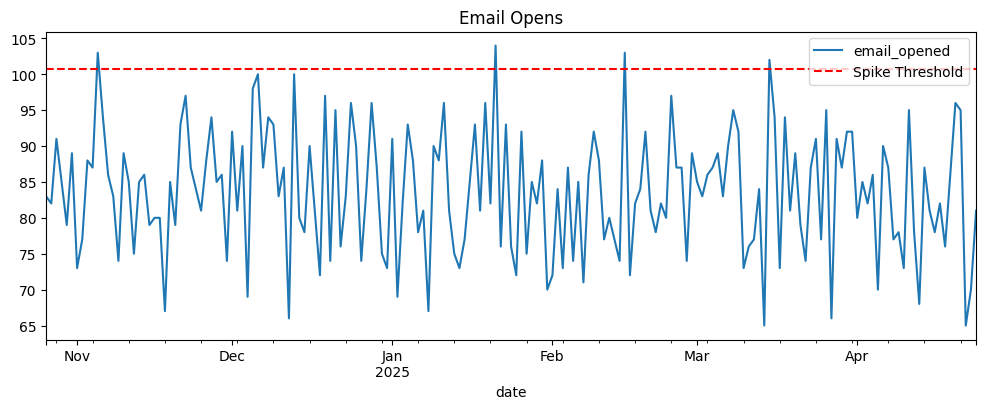

In [4]:
summary_df["email_opened"].plot(figsize=(12, 4), title="Email Opens")
plt.axhline(summary_df["email_opened"].mean() + 2 * summary_df["email_opened"].std(), color='red', linestyle='--', label='Spike Threshold')
plt.legend()
plt.show()

#  Forecasting with ARIMA

/usr/local/lib/python3.8/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.8/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.8/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


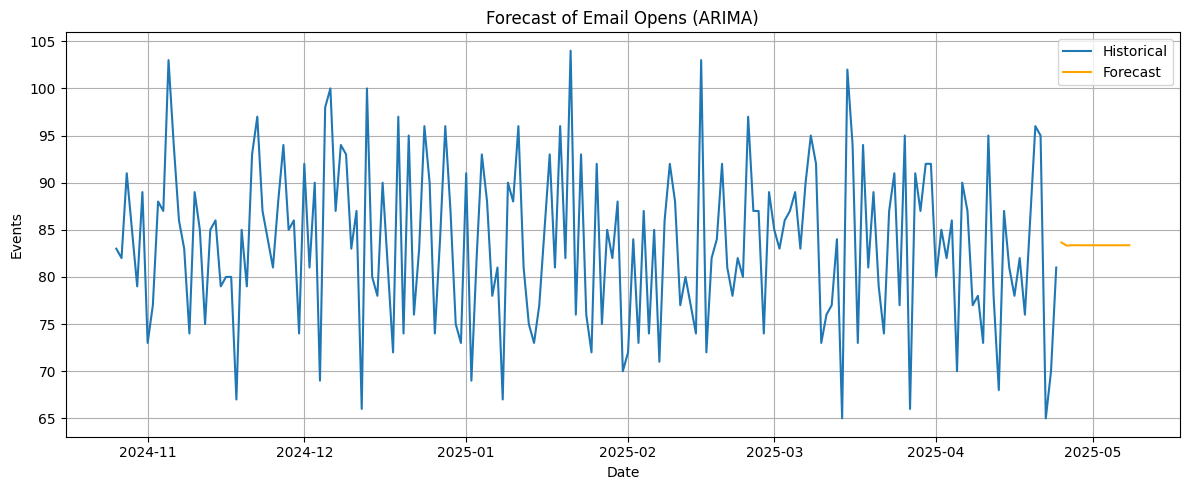

In [5]:
from statsmodels.tsa.arima.model import ARIMA

# Use email_opened for forecasting
series = summary_df["email_opened"]

# Fit ARIMA model (simple ARIMA(1,1,1))
model = ARIMA(series, order=(1, 1, 1))
model_fit = model.fit()

# Forecast next 14 days
forecast = model_fit.forecast(steps=14)
forecast.index = pd.date_range(start=series.index[-1] + pd.Timedelta(days=1), periods=14)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(series, label="Historical")
plt.plot(forecast, label="Forecast", color="orange")
plt.title("Forecast of Email Opens (ARIMA)")
plt.xlabel("Date")
plt.ylabel("Events")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Anomaly Detection (Simple Z-score or Threshold)

In [6]:
from scipy.stats import zscore

summary_df["zscore_email"] = zscore(summary_df["email_opened"])
anomalies = summary_df[summary_df["zscore_email"].abs() > 2]

print("📉 Anomalies Detected:")
print(anomalies[["email_opened", "zscore_email"]])

📉 Anomalies Detected:
event_name  email_opened  zscore_email
date                                  
2024-11-05           103      2.263521
2024-12-12            66     -2.058920
2025-01-21           104      2.380344
2025-02-15           103      2.263521
2025-03-14            65     -2.175743
2025-03-15           102      2.146698
2025-03-27            66     -2.058920
2025-04-22            65     -2.175743
